In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import skimage as ski
from natsort import natsorted
from plate_segmentation import PlateSegmenter
from tqdm.notebook import tqdm

In [2]:
# get file paths to phenotype-o-mat image data
input_directory = Path(
    "/Users/ryanlane/Projects/2024-segment-colonies/data/phenotype-o-mat/2024-09-16"
)
jpg_filepaths = natsorted(input_directory.glob("*.jpg"))

### Single image

In [3]:
# optional segmentation parameters
segmentation_parameters = {
    "plate_radius_px": 525,
    "sigma_low": 2,
    "min_colony_size_px2": 24,
}

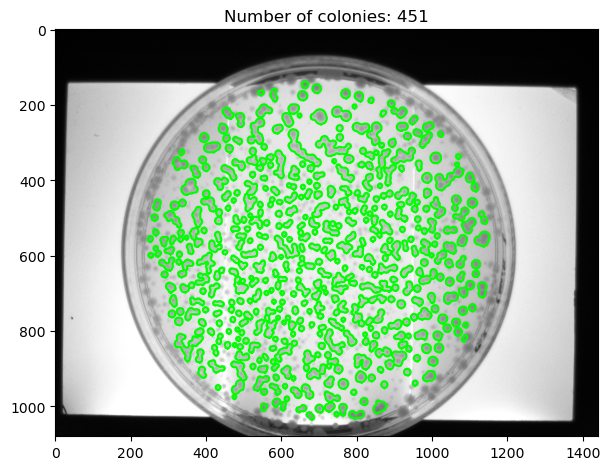

In [4]:
# load phenotype-o-mat image
filename = jpg_filepaths[0]
raw_plate_image = ski.io.imread(filename)
plate_segmenter = PlateSegmenter(filename=filename, **segmentation_parameters)
# segment colonies
segmented_plate_image = plate_segmenter.segment()

# plot raw image
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(raw_plate_image, cmap="Greys_r")

# plot contours of each detected colony
colony_segments = ski.measure.regionprops(segmented_plate_image)
for i, _ in enumerate(colony_segments):
    contour = ski.measure.find_contours(segmented_plate_image == i + 1)[0]
    ax.plot(contour[:, 1], contour[:, 0], color="#00ff00")

# aesthetics
title = f"Number of colonies: {len(colony_segments)}"
ax.set_title(title);

### Batch of images

  0%|          | 0/5 [00:00<?, ?it/s]

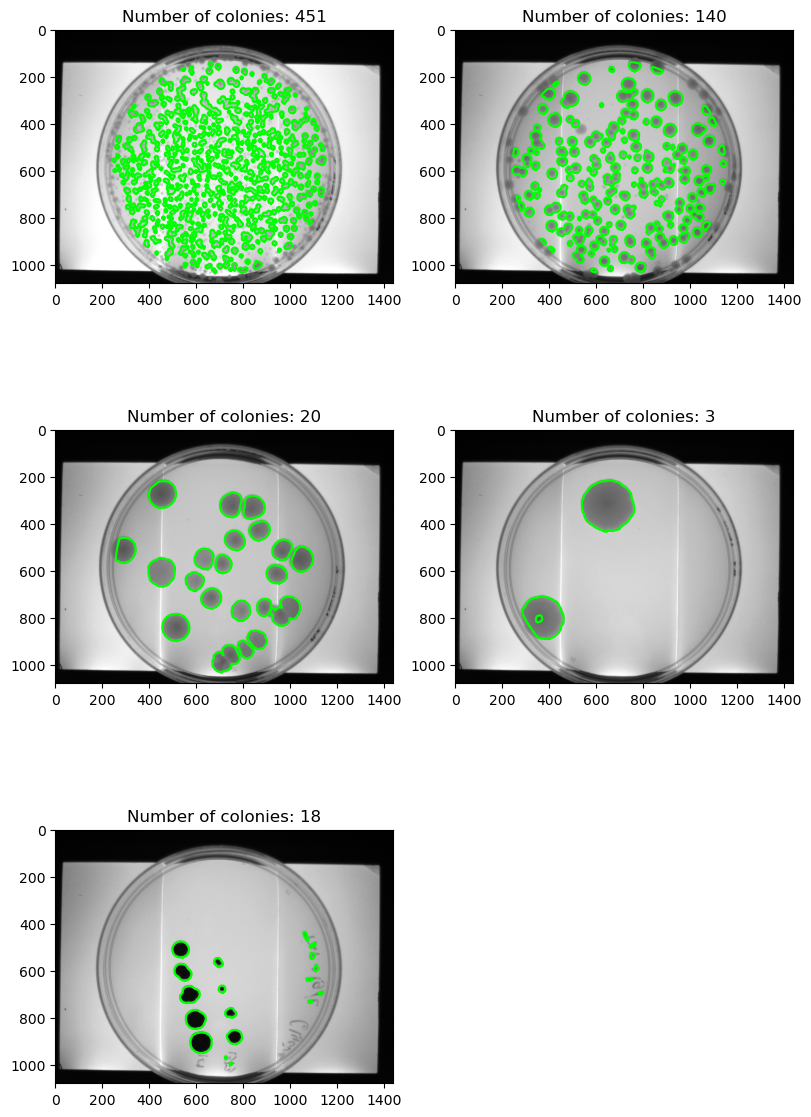

In [5]:
# create figure
ncols = 2
nrows = int(math.ceil(len(jpg_filepaths) / ncols))
fig, axes = plt.subplots(
    ncols=ncols, nrows=nrows, layout="constrained", figsize=(4 * ncols, 4 * nrows)
)

for i, filename in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    #
    ax = axes.flat[i]

    raw_plate_image = ski.io.imread(filename)
    plate_segmenter = PlateSegmenter(filename=filename, **segmentation_parameters)
    segmented_plate_image = plate_segmenter.segment()

    ax.imshow(raw_plate_image, cmap="Greys_r")

    # plot contours of each detected colony
    colony_segments = ski.measure.regionprops(segmented_plate_image)
    for i, _ in enumerate(colony_segments):
        contour = ski.measure.find_contours(segmented_plate_image == i + 1)[0]
        ax.plot(contour[:, 1], contour[:, 0], color="#00ff00")

    # aesthetics
    title = f"Number of colonies: {len(colony_segments)}"
    ax.set_title(title)

# delete empty axes
[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];